# LABS figures and tables

Reproduces the following figures/tables from the paper: Figures 20, 21, and Tables 3, 6. The code for this notebook has been extracted from the scripts `labs_depth_sweep.py`, `labs_landscape.py`, and
`labs_tables.py`.

In [18]:
import json
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

## Statevector helpers

In [19]:
import numpy as np

try:
    import cupy as xp
except ImportError:
    xp = np


def labs_energies(n):
    """Sidelobe energy E(s) = sum_{k>=1} (sum_i s_i s_{i+k})^2 of every length-n sequence.

    Indexed by computational basis state, with x_i = 0, 1 mapped to s_i = +1, -1.
    """
    s = np.where((np.arange(2 ** n)[:, None] >> np.arange(n)) & 1, -1, 1).astype(np.int32)
    e = np.zeros(2 ** n)
    for k in range(1, n):
        c = (s[:, : n - k] * s[:, k:]).sum(1)
        e += c * c
    return e


def _mix(psi, beta):
    # exp(-i beta X) on each qubit in turn, in place
    c, s = np.cos(beta), -1j * np.sin(beta)
    n = psi.shape[0].bit_length() - 1
    for j in range(n):
        v = psi.reshape(-1, 2, 2 ** j)
        lo = v[:, 0].copy()
        v[:, 0] = c * lo + s * v[:, 1]
        v[:, 1] = s * lo + c * v[:, 1]
    return psi


def qaoa_state(energies, angles):
    """Statevector of the p-layer QAOA circuit; returned on the host as a numpy array."""
    e = xp.asarray(energies)
    p = len(angles) // 2
    betas, gammas = angles[:p], angles[p:]
    psi = xp.full(len(e), len(e) ** -0.5, dtype=complex)
    for gamma, beta in zip(gammas, betas):
        psi = _mix(psi * xp.exp(-1j * gamma * e), beta)
    return xp.asnumpy(psi) if xp is not np else psi


def energy_mf_tts(energies, angles):
    """Return (energy, mean merit factor, time-to-solution) of the QAOA state."""
    n = len(energies).bit_length() - 1
    prob = np.abs(qaoa_state(energies, angles)) ** 2
    p_opt = prob[energies == energies.min()].sum()
    mf = (prob * n * n / (2 * energies)).sum()
    tts = 1 / p_opt if p_opt > 0 else np.inf
    return prob @ energies, mf, tts

## Plot styling

In [20]:
# We use Paul Tol's bright colour scheme
# Define color mapping for each method variant (with optimization markers * and †)
method_to_colour = {
    "Fixed Angles*": "#4477AA",
    "Fixed Angles": "#4477AA",
    "Fixed Angles†": "#4477AA",
    "Fourier*": "#EE6677",
    "Fourier": "#EE6677",
    "Interp.*": "#228833",
    "Interp.": "#228833",
    "Linear Ramp*": "#CCBB44",
    "Linear Ramp": "#CCBB44",
    "Linear Ramp†": "#CCBB44",
    "Recursive TS": "#66CCEE",
    "TQA*": "#AA3377",
    "TQA": "#AA3377",
    "TQA†": "#AA3377",
    "Parameter Transfer": "#BBBBBB",
}

# Define marker shapes for different evaluation methods
evaluation_markers = {
    "SV": "o",
    "MPS (Quimb)": "P",
    "MPS (Aer)": "^",
    "PP": "s",
}


def style_scatter(method: str, evaluation: str) -> dict:
    """Return a style dictionary suitable for :fun:`matplotlib.pyplot.scatter`.

    Args:
        method: The method label, with ``"*"`` or ``"†"`` if the method is
            optimised or unoptimised.
        evaluation: The energy evaluation method label, e.g., ``"SV"``, ``"MPS
            (Aer)"``, ``"MPS (Quimb)"``, or ``"PP"``.

    Returns:
        A dictionary of kwargs appropriate for matplotlib's scatter function.
    """
    # Configure marker styling based on optimization status:
    # - "*" (optimized angles): black edge, colored fill
    # - "†" (unoptimized): colored edge, white fill
    # - neither: no edge, colored fill
    return {
        "edgecolor": "k"
        if "*" in method
        else (method_to_colour[method] if "†" in method else "None"),
        "marker": evaluation_markers[evaluation],
        "color": method_to_colour[method] if "†" not in method else "None",
        "facecolor": "w" if "†" in method else method_to_colour[method],
    }


def style_plot(method: str, evaluation: str) -> dict:
    """Return a style dictionary suitable for :fun:`matplotlib.pyplot.plot`.

    Args:
        method: The method label, with ``"*"`` or ``"†"`` if the method is
            optimised or unoptimised.
        evaluation: The energy evaluation method label, e.g., ``"SV"``, ``"MPS
            (Aer)"``, ``"MPS (Quimb)"``, or ``"PP"``.

    Returns:
        A dictionary of kwargs appropriate for matplotlib's plot function.
    """
    # Start with scatter styling
    kwargs = style_scatter(method=method, evaluation=evaluation)
    # Rename entries from scatter() kwargs to plot() kwargs
    kwargs["markerfacecolor"] = kwargs.pop("facecolor")
    kwargs["markeredgecolor"] = kwargs.pop("edgecolor")
    # Set line color to method color
    kwargs["color"] = method_to_colour[method]
    return kwargs


def figsize(
    aspect_ratio: float = 1.0, two_columns: bool = False
) -> tuple[float, float]:
    # Calculate figure dimensions based on column layout
    if two_columns:
        width = 7.0
    else:
        width = 3.4
    height = width / aspect_ratio
    return (width, height)

## Depth sweep figure (Figure 21)

In [21]:
# APS-like plotting style with LaTeX text rendering.
mpl.rcParams.update(
    {
        "figure.figsize": (3.4, 2.5),  # default single-column figure
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.7,
        "lines.linewidth": 1.0,
        "lines.markersize": 3.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "mathtext.fontset": "stix",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    }
)

DATA = Path("../data/simulations/labs")
HERE = Path(".")

plot_order = ("F", "I", "trivial", "LR", "LR*", "TQA", "TQA*", "RTS")
_KEY_TO_LABEL = {
    "F": "Fourier",
    "I": "Interp.",
    "LR": "Linear Ramp",
    "LR*": "Linear Ramp*",
    "TQA": "TQA",
    "TQA*": "TQA*",
    "RTS": "Recursive TS",
}
_REF_OPTIMAL = "#2d2d2d"
_REF_UNIFORM = "tab:cyan"
_TRIVIAL_STYLE = {"color": "#777777", "linestyle": ":", "marker": None, "linewidth": 0.9}


def recursive_series(folder, n, e):
    """(depths, energies, merit factors, TTS) for a recursive run (Fourier / Interp.)."""
    data = json.load(open(glob(str(DATA / folder / f"*labs_{n}_*"))[0]))
    depths = [1] + sorted(int(k) for k in data["2"] if k.isdigit())
    rows = [energy_mf_tts(e, np.array((data["1"] if d == 1 else data["2"][str(d)])["optimized_qaoa_angles"]))
            for d in depths]
    energies, mfs, tts = zip(*rows)
    return depths, list(energies), list(mfs), list(tts)


def linear_ramp_series(n, e):
    """(depths, energies, merit factors, TTS) taking the best initial slope at each depth."""
    depths = sorted({int(f.rsplit("depth_", 1)[1].split(".")[0]) for f in glob(str(DATA / "LR" / f"*labs_{n}_*"))})
    depths = [d for d in depths if d <= 50]
    energies, mfs, tts = [], [], []
    for d in depths:
        best = min((json.load(open(f))["1"] for f in glob(str(DATA / "LR" / f"*labs_{n}_*depth_{d}.json"))),
                   key=lambda r: r["energy"])
        E, mf, t = energy_mf_tts(e, np.array(best["optimized_qaoa_angles"]))
        energies.append(E); mfs.append(mf); tts.append(t)
    return depths, energies, mfs, tts


def figure(n):
    e = labs_energies(n)
    series = {"F": recursive_series("F", n, e), "I": recursive_series("I", n, e), "LR*": linear_ramp_series(n, e)}

    opt_E = e.min()
    opt_MF = n * n / (2 * opt_E)
    tts_uniform = 2 ** n / (e == opt_E).sum()
    uniform_E = e.mean()
    uniform_MF = (n * n / (2 * e)).mean()

    fig, axes = plt.subplots(1, 3, figsize=figsize(aspect_ratio=6.8 / 2.1, two_columns=True))
    handles, labels = [], []

    ax = axes[0]
    for key in plot_order:
        if key not in series:
            continue
        depths, _, _, tts_list = series[key]
        y = np.where(np.isfinite(tts_list) & (np.asarray(tts_list) > 0), tts_list, np.nan)
        label = _KEY_TO_LABEL[key]
        (line,) = ax.semilogy(depths, y, linestyle="-", label=label, **style_plot(label, "SV"))
        handles.append(line)
        labels.append(label)
    line_ideal = ax.axhline(1, color=_REF_OPTIMAL, linestyle="--", linewidth=0.8)
    line_random_tts = ax.axhline(tts_uniform, color=_REF_UNIFORM, linestyle=":", linewidth=0.8)
    ax.set_xlabel("Depth $p$")
    ax.set_ylabel("TTS")
    ax.grid(True, alpha=0.3, which="both")

    ax = axes[1]
    for key in plot_order:
        if key not in series:
            continue
        depths, energies, _, _ = series[key]
        ax.plot(depths, energies, linestyle="-", **style_plot(_KEY_TO_LABEL[key], "SV"))
    ax.axhline(opt_E, color=_REF_OPTIMAL, linestyle="--", linewidth=0.8)
    ax.axhline(uniform_E, color=_REF_UNIFORM, linestyle=":", linewidth=0.8)
    ax.set_xlabel("Depth $p$")
    ax.set_ylabel("LABS energy")
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    for key in plot_order:
        if key not in series:
            continue
        depths, _, mfs, _ = series[key]
        ax.plot(depths, mfs, linestyle="-", **style_plot(_KEY_TO_LABEL[key], "SV"))
    ax.axhline(opt_MF, color=_REF_OPTIMAL, linestyle="--", linewidth=0.8)
    ax.axhline(uniform_MF, color=_REF_UNIFORM, linestyle=":", linewidth=0.8)
    ax.set_xlabel("Depth $p$")
    ax.set_ylabel("Merit factor")
    ax.grid(True, alpha=0.3)

    all_handles = handles + [line_ideal, line_random_tts]
    all_labels = labels + ["Optimal", "Uniform Sampling"]
    fig.tight_layout(rect=[0, 0, 1, 0.74])
    fig.legend(all_handles, all_labels, loc="upper center", ncol=len(all_handles),
               frameon=False, bbox_to_anchor=(0.5, 0.82))
    fig.savefig(HERE / "method_comparison_N_{}.pdf".format(n))
    # NOTE: the standalone script calls plt.close(fig) here since it's a batch job;
    # left open (not closed) so the notebook's inline backend displays each figure.

In [22]:
figure(21)

KeyboardInterrupt: 

## LABS energy landscape (Figure 20)

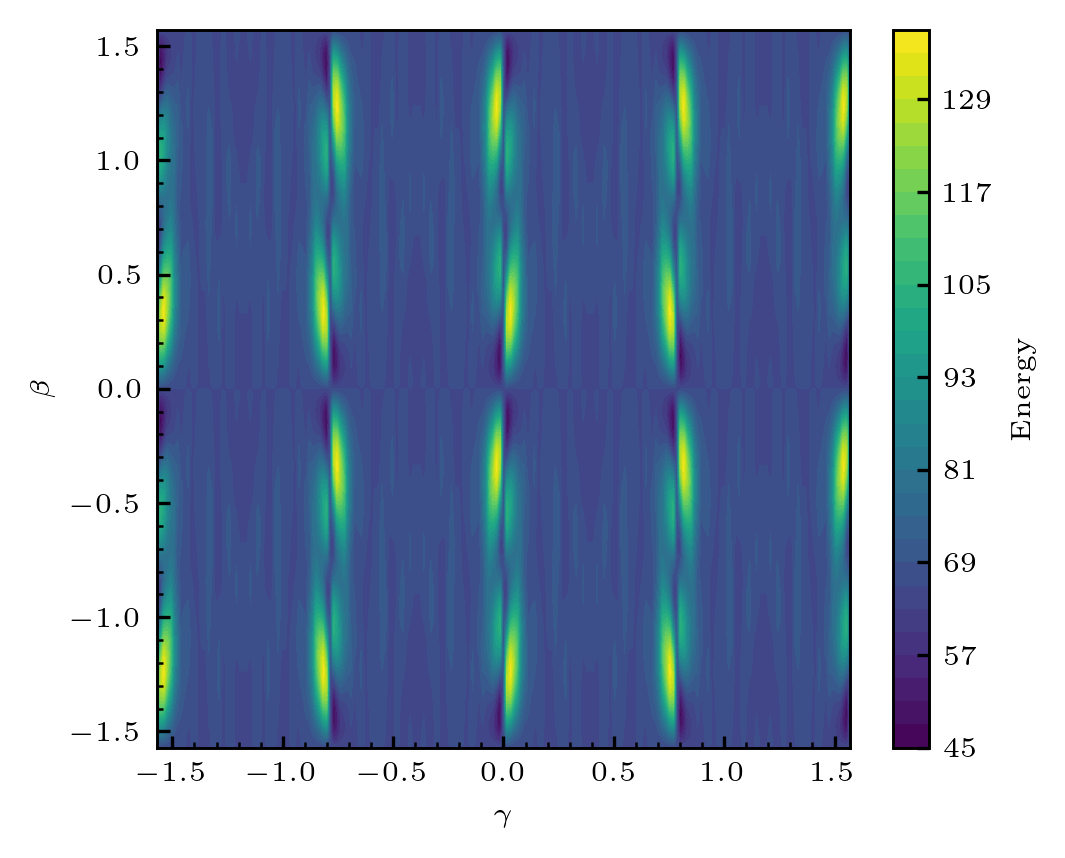

In [ ]:
import shutil

if shutil.which("latex"):
    plt.rcParams["text.usetex"] = True
plt.rcParams.update({"axes.labelsize": "small", "xtick.labelsize": "small", "ytick.labelsize": "small"})

n = 12
e = xp.asarray(labs_energies(n))
grid = np.linspace(-np.pi / 2, np.pi / 2, 201)
g = xp.asarray(grid)

# psi[b, m] is the state at beta = grid[b], gamma = grid[m]: mix(beta) applied to exp(-i gamma H)|+>
psi = xp.broadcast_to(xp.exp(-1j * g[None, :, None] * e) * e.size ** -0.5, (grid.size, grid.size, e.size)).copy()
cos, sin = xp.cos(g).reshape(-1, 1, 1, 1), (-1j * xp.sin(g)).reshape(-1, 1, 1, 1)
for q in range(n):
    v = psi.reshape(grid.size, grid.size, -1, 2, 2 ** q)
    lo = v[:, :, :, 0, :].copy()
    v[:, :, :, 0, :] = cos * lo + sin * v[:, :, :, 1, :]
    v[:, :, :, 1, :] = sin * lo + cos * v[:, :, :, 1, :]
energy = (xp.abs(psi) ** 2 * e).sum(-1)
energy = xp.asnumpy(energy) if xp is not np else energy

fig, ax = plt.subplots(figsize=(3.6, 2.9))
cs = ax.contourf(grid, grid, energy, levels=30)
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\beta$")
fig.colorbar(cs, ax=ax, label="Energy")
fig.tight_layout()
fig.savefig(HERE / "landscape.pdf")

## LABS tables (Tables III and VI)

In [ ]:
DATA = Path("../data/simulations/labs")
HERE = Path(".")

# label, folder, result key.  "*" rows read the Scipy-refined angles (key "1"), the plain rows the
# schedule they start from (key "0"); the recursive methods keep everything in one file.
METHODS = [("Fourier", "F", None), ("Interp.", "I", None), ("Trivial", "trivial", None),
           ("RTS", "RTS", "2"), ("TQA", "TQA", "0"), ("TQA*", "TQA", "1"),
           ("LR", "LR", "0"), ("LR*", "LR", "1")]


def best_run(folder, key, n):
    """(energy, angles) the table keeps for a method at instance n.

    F/I/trivial hold the whole depth sweep in one recursive file (depth 50 under key "2"), RTS the
    best recursive state at p = 10 (key "2"), LR/TQA the best of the four initial slopes at p = 50.
    """
    if key is None:
        r = json.load(open(glob(str(DATA / folder / f"*labs_{n}_*"))[0]))["2"]["50"]
    elif key == "2":
        r = json.load(open(glob(str(DATA / folder / f"*labs_{n}_*"))[0]))["2"]
    else:
        runs = (json.load(open(f))[key] for f in glob(str(DATA / folder / f"*labs_{n}_*depth_50.json")))
        r = min(runs, key=lambda r: r["energy"])
    return r["energy"], np.array(r["optimized_qaoa_angles"])


def evaluate(nodes):
    energy, mfnorm, tts = {}, {}, {}
    for n in nodes:
        e = labs_energies(n)
        mf_opt = n * n / (2 * e.min())
        for label, folder, key in METHODS:
            _, angles = best_run(folder, key, n)
            E, mf, t = energy_mf_tts(e, angles)
            energy[label, n], mfnorm[label, n], tts[label, n] = E, mf / mf_opt, t
    return energy, mfnorm, tts


def fmt_tts(t):
    return "{:.1f}".format(t) if t < 100 else ("{:.0f}".format(t) if t < 1e4 else "{:.0e}".format(t))


nodes = list(range(10, 22))
energy, mfnorm, tts = evaluate(nodes)
optimal = {n: int(labs_energies(n).min()) for n in nodes}

# --- Table VI: energy, n = 10..21 ---
print("energy (depth 50; RTS depth 10)")
print("      " + "".join("{:>7}".format(n) for n in nodes))
for label, _, _ in METHODS:
    print("{:<8}".format(label) + "".join("{:>7.1f}".format(energy[label, n]) for n in nodes))
print("{:<8}".format("Optimal") + "".join("{:>7d}".format(optimal[n]) for n in nodes))

with open(HERE / "energy.tex", "w") as f:
    f.write("\\begin{tabular}{l" + "r" * len(nodes) + "}\n\\hline\n")
    f.write(" & " + " & ".join(str(n) for n in nodes) + " \\\\\n\\hline\n")
    for label, _, _ in METHODS:
        f.write(label + " & " + " & ".join("{:.1f}".format(energy[label, n]) for n in nodes) + " \\\\\n")
    f.write("Optimal & " + " & ".join(str(optimal[n]) for n in nodes) + " \\\\\n\\hline\n\\end{tabular}\n")

# --- Table III: normalised merit factor and TTS, n = 14..21 ---
cols = list(range(14, 22))
print("\nnormalised merit factor, time-to-solution (depth 50)")
print("      " + "".join("{:>14}".format(n) for n in cols))
for label, _, _ in METHODS:
    row = ["{:.2f}, {}".format(mfnorm[label, n], fmt_tts(tts[label, n])) for n in cols]
    print("{:<8}".format(label) + "".join("{:>14}".format(c) for c in row))

with open(HERE / "merit_tts.tex", "w") as f:
    f.write("\\begin{tabular}{l" + "r" * len(cols) + "}\n\\hline\n")
    f.write(" & " + " & ".join(str(n) for n in cols) + " \\\\\n\\hline\n")
    for label, _, _ in METHODS:
        cells = ["({:.2f}, {})".format(mfnorm[label, n], fmt_tts(tts[label, n])) for n in cols]
        f.write(label + " & " + " & ".join(cells) + " \\\\\n")
    f.write("\\hline\n\\end{tabular}\n")

energy (depth 50; RTS depth 10)
           10     11     12     13     14     15     16     17     18     19     20     21
Fourier    13.6    5.9   12.7   15.8   20.8   24.8   31.1   38.1   38.4   43.3   49.1   54.4
Interp.    13.4    6.1   12.4   16.1   20.6   25.0   31.5   38.2   38.8   43.6   49.7   55.3
Trivial    14.2   17.6   16.8   22.8   25.3   30.4   35.5   42.3   45.1   51.1   56.1   64.8
RTS        18.4   22.4   25.1   27.9   32.2   38.5   44.9   52.1   58.1   65.0   71.6   78.6
TQA        42.1   51.9   65.5   73.5   89.0  103.6  116.8  135.0  152.3  170.3  189.4  209.2
TQA*       31.7   39.9   55.0   65.9   83.4   98.4  112.9  132.0  149.8  168.4  187.3  207.0
LR         15.0   16.7   18.2   21.4   25.3   29.8   35.2   41.9   45.5   51.0   56.6   62.6
LR*        14.0   15.7   16.5   20.5   24.4   28.7   34.2   40.9   43.8   49.1   54.8   60.7
Optimal      13      5     10      6     19     15     24     32     25     29     26     26

normalised merit factor, time-to-soluti